In [26]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
titanic = pd.read_csv("Titanic.csv")

In [28]:
titanic.shape

(891, 12)

In [29]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [30]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [31]:
titanic.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [32]:
titanic.isnull().sum()
### Age=177
### Cabin = 687
### Embarked = 2


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

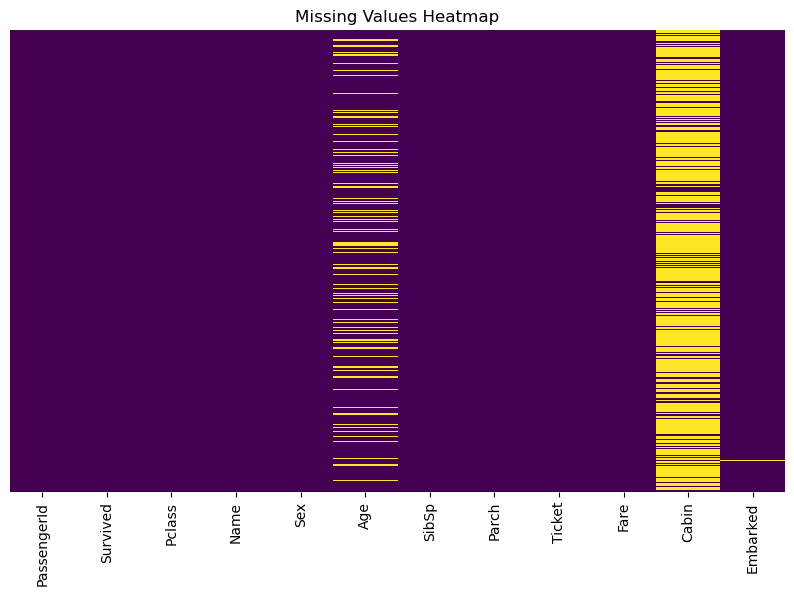

In [33]:
plt.figure(figsize=(10,6))

sns.heatmap(titanic.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [34]:
titanic['Age'].fillna(titanic['Age'].median(), inplace=True)
titanic['Embarked'].fillna(titanic['Embarked'].mode()[0], inplace=True)
titanic.drop('Cabin', axis=1, inplace=True)

C:\Users\LapTechnology\AppData\Local\Temp\ipykernel_10652\759001133.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['Age'].fillna(titanic['Age'].median(), inplace=True)
C:\Users\LapTechnology\AppData\Local\Temp\ipykernel_10652\759001133.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

In [35]:
numeric = titanic.select_dtypes(include=['int64', 'float64'])
categorical = titanic.select_dtypes(include=['object'])

print("Numeric Features:", numeric.columns.tolist())
print("Categorical Features:", categorical.columns.tolist())

Numeric Features: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical Features: ['Name', 'Sex', 'Ticket', 'Embarked']


In [36]:
##Cheak
titanic.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [37]:
titanic.duplicated().sum()

0

### Visualization

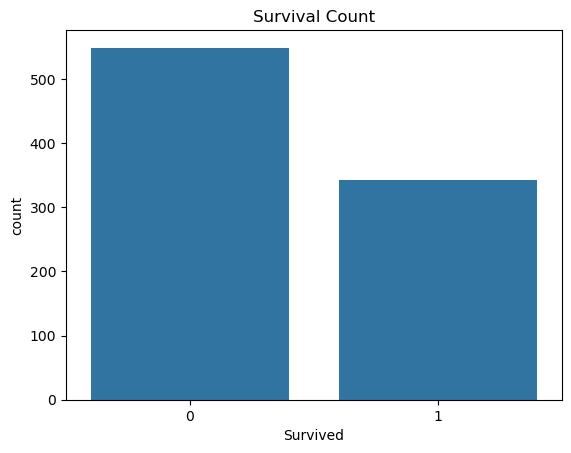

In [38]:
#1
sns.countplot(x='Survived', data=titanic)
plt.title('Survival Count')
plt.show()

##### The number of passengers who did not survive was higher than the number of survivors. This indicates that more than half of the passengers lost their lives in the Titanic disaster.

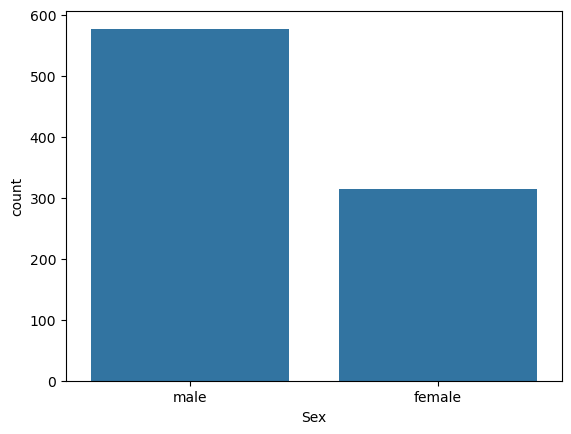

In [40]:
sns.countplot(x='Sex',data=titanic)
plt.show()

##### Male passengers were more numerous than female passengers on the Titanic.

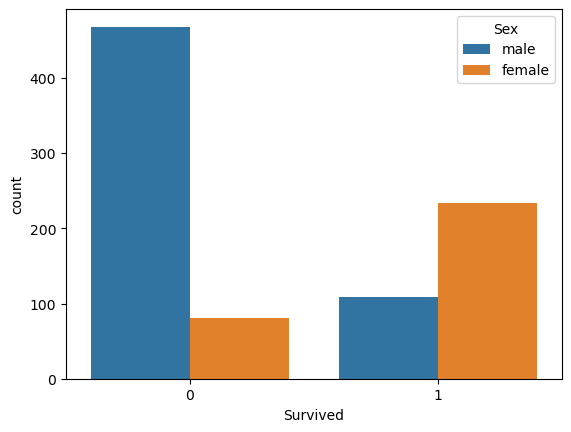

In [42]:
sns.countplot(x='Survived',hue='Sex',data=titanic)
plt.show()

##### Female passengers had a significantly higher survival rate than male passengers. This suggests that women were given higher priority during the evacuation process.

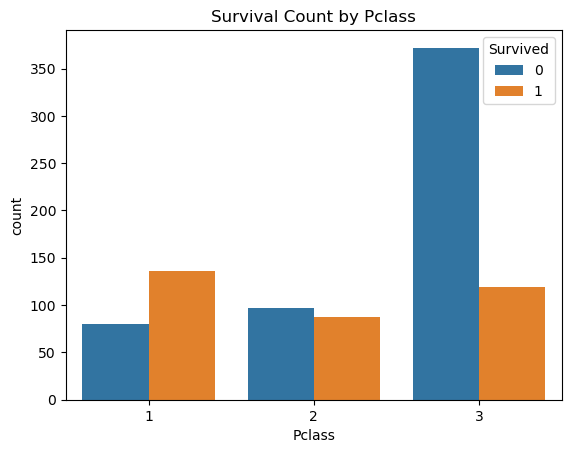

In [43]:
sns.countplot(x='Pclass',hue='Survived',data=titanic)
plt.title('Survival Count by Pclass')
plt.show()

##### Passengers in the first class had the highest survival rate, while those in the third class had the lowest. This suggests that passenger class had a strong influence on survival.

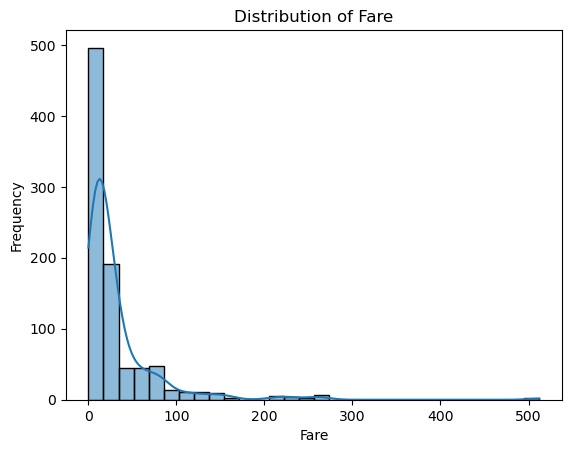

In [44]:
sns.histplot(titanic['Fare'], bins=30, kde=True)
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

##### The fare distribution is highly right-skewed. Most passengers paid relatively low fares, while a small number paid much higher ticket prices.

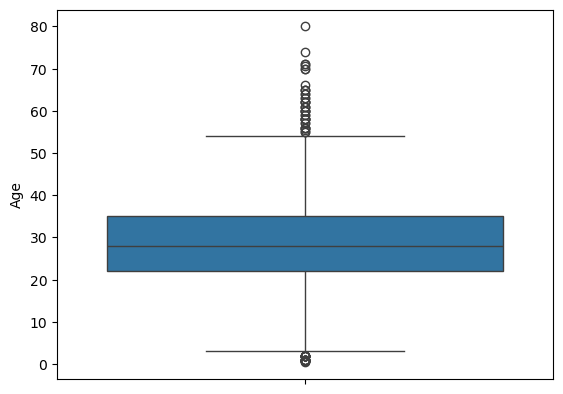

In [46]:
sns.boxplot(y='Age',data=titanic)
plt.show()

##### The boxplot shows a few outliers representing very young children and elderly passengers. Most passengers' ages fall within a moderate range.

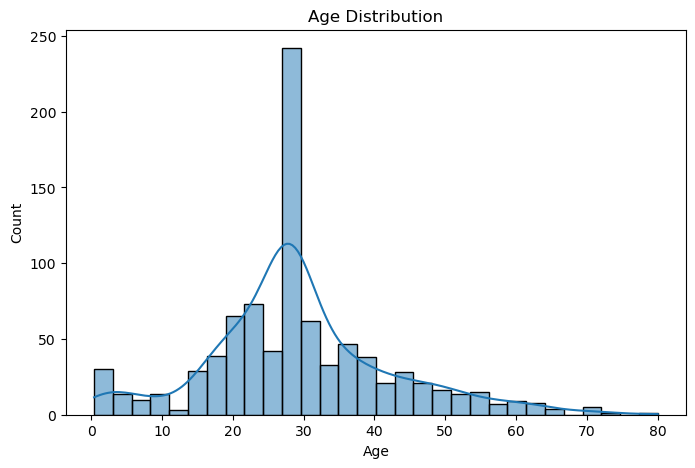

In [51]:
plt.figure(figsize=(8,5))
sns.histplot(titanic["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

##### Most passengers were between 20 and 40 years old. The age distribution appears approximately normal with fewer elderly passengers.

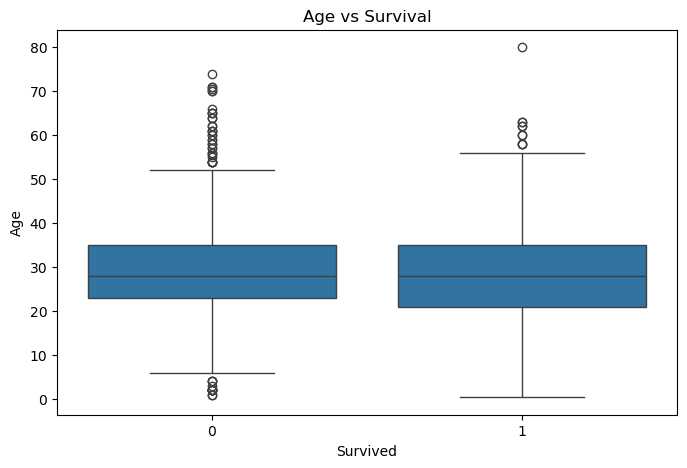

In [55]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Survived", y="Age", data=titanic)
plt.title("Age vs Survival")
plt.show()

##### The age distributions of survivors and non-survivors are similar, although younger passengers appear to have had slightly better survival chances.

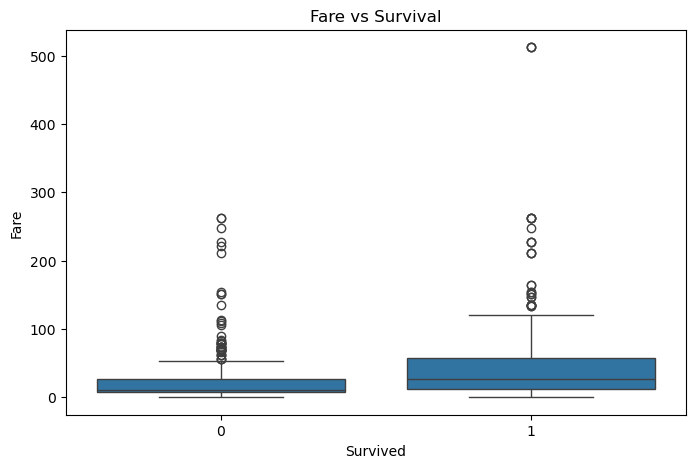

In [56]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Survived", y="Fare", data=titanic)
plt.title("Fare vs Survival")
plt.show()

##### Survivors generally paid higher fares than non-survivors, suggesting that passengers with more expensive tickets had a greater chance of survival.

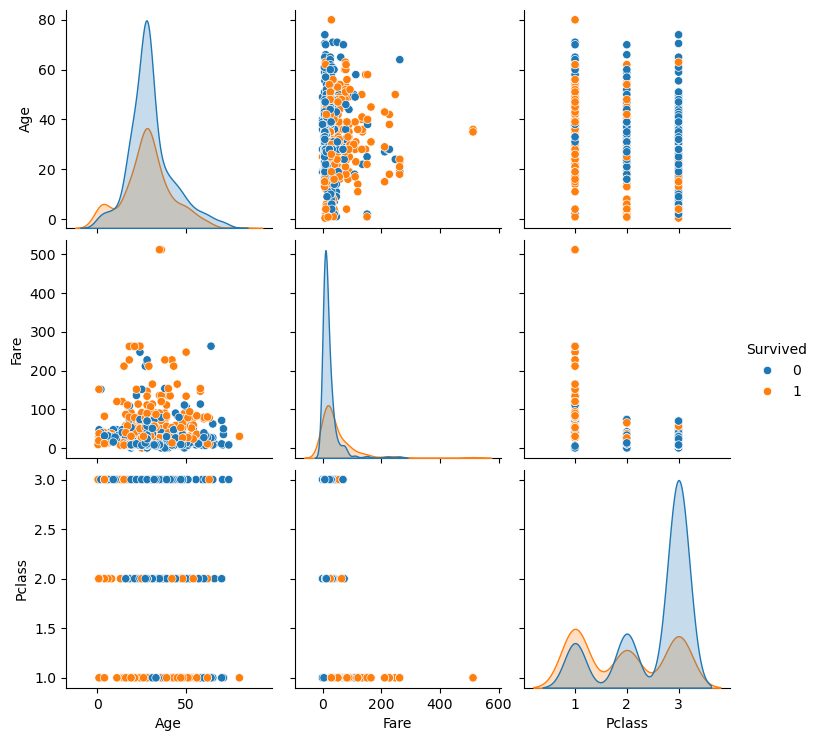

In [53]:
sns.pairplot(
    titanic[["Age", "Fare", "Pclass", "Survived"]],
    hue="Survived"
)
plt.show()

##### The pairplot reveals relationships among numerical variables. Survivors tend to be associated with higher fares and lower passenger class values, while age alone does not clearly separate survivors from non-survivors.

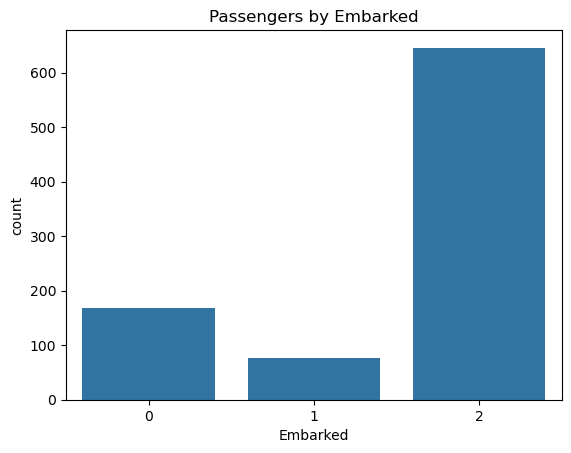

In [54]:
sns.countplot(x="Embarked", data=titanic)
plt.title("Passengers by Embarked")
plt.show()

##### Most passengers boarded the Titanic from Southampton (S), while fewer passengers embarked from Cherbourg (C) and Queenstown (Q).

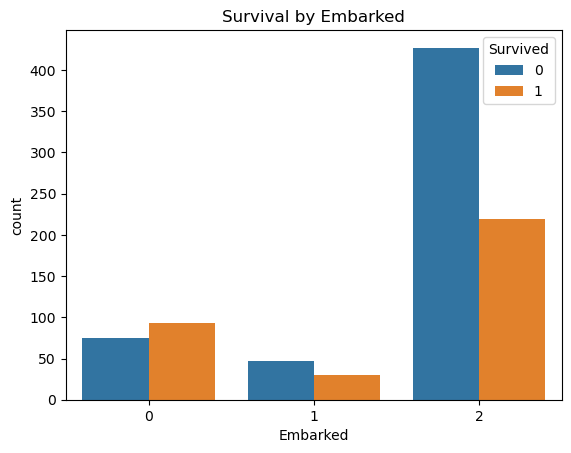

In [52]:
sns.countplot(x="Embarked", hue="Survived", data=titanic)
plt.title("Survival by Embarked")
plt.show()

##### Survival rates varied by embarkation port. Passengers who boarded at Cherbourg appeared to have a higher survival rate compared to the other ports.

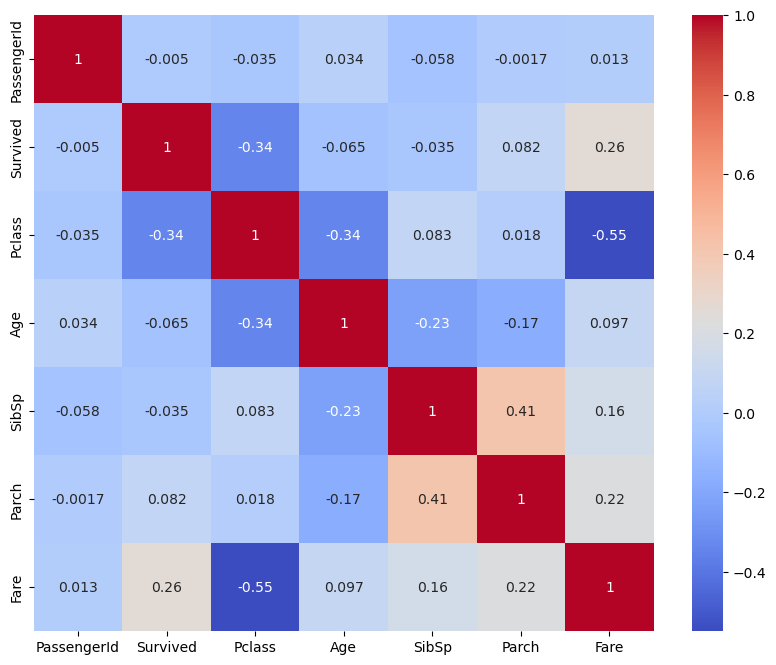

In [48]:
numeric = titanic.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(numeric.corr(),
            annot=True,
            cmap="coolwarm")
plt.show()

##### The heatmap shows that Fare has a positive correlation with survival, while Pclass has a negative correlation with survival. This indicates that passengers who paid higher fares and traveled in higher classes were more likely to survive.

In [50]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic["Sex"] = le.fit_transform(titanic["Sex"])
titanic["Embarked"] = le.fit_transform(titanic["Embarked"])

In [57]:
###Prepare the data for modeling
X = titanic.drop(["Survived", "PassengerId", "Name", "Ticket"], axis=1)
y = titanic["Survived"]

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [60]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [61]:
y_pred = model.predict(X_test)

In [62]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7988826815642458


In [63]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[97 13]
 [23 46]]


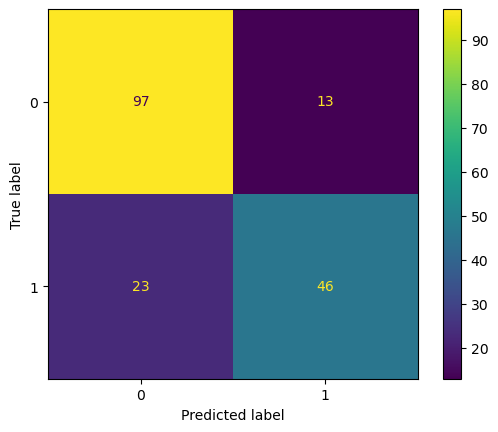

In [64]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [81]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179

